# Detectarea tranzacțiilor financiare frauduloase
## Detactarea anomaliilor
### Student: Bicu David-Mihai
### Grupa: 334AB

## **1. Descrierea problemei**
O problemă importantă în sectorul financiar reprezintă fraudele bancare, scopul acestui proiect fiind de a găsi o metodă de învățare automată nesupervizată prin care putem identifica automat tranzacțiile bancare frauduloase.

Tranzacțiile frauduloase sunt evenimente rare și izolate ce nu se încadrează în tiparul tranzacțiilor bancare normale. Scopul proiectului nu este de a găsi noi tipare pe care să se suprapună o bună parte din date, ci de a identifica acele instanțe izolate ce diferă faorte mult de tranzacțiile bancare normale.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pentru preprocesare și metrici
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## **2. Preprocesarea și exploatarea datelor**
Setul de date este unul istoric, fiind preluat de pe [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data):

In [3]:
df = pd.read_csv('creditcard.csv')
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Setul de date `creditcard.csv` are 284807 instanțe și 31 de caracteristici, acestea fiind:
- `Time` (variabilă de tipul `float64`) - momentul de timp (măsurat în secunde) raportat la prima tranzacție (motiv pentru care primele 2 instanțe au $0.0$ la `Time`);
- `V1`,`V2`,...,`V27`,`V28` (fiecare de tipul `float64`) - caracteristicile principale ale utilizatorilor obținute în urma implementării algoritmului PCA;
- `Amount` (variabilă de tipul `float64`) - suma tranzacționată
- `Class` (variabilă binară) - tipul de tranzacție:
    - $0$ - tranzacție normală
    - $1$ - tranzacție frauduloasă 


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Verificăm proporționalitatea celor 2 clase cu scopul de a stabili modul de abordare a problemei.

In [6]:
print(df['Class'].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


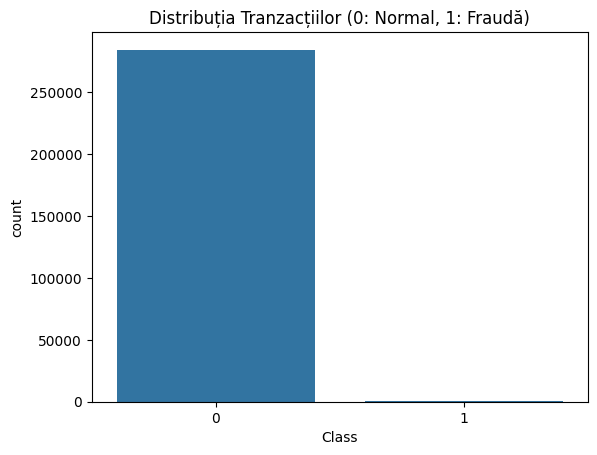

In [7]:
sns.countplot(x='Class', data=df)
plt.title('Distribuția Tranzacțiilor (0: Normal, 1: Fraudă)')
plt.show()

Setul de date este etichetat, ceea ce înseamnă că am putea trata problema din perspectiva **Clasificării binare**. Cu toate acestea, raportul este de 99.82% tranzacții din *Clasa 0* (tranzacții normale), ceea ce ar fi foarte dificil pentru orice model supervizat să-l învețe bine, motiv pentru voi trata problema ca o problemă nesupervizată, considerând tranzacțiile frauduloase drept *anomalii*, problema devenind una de tipul **Detectarea anomaliilor**.

De asemenea, pentru a rezolva această problemă, voi renunța la coloanele `Time`, deoarece momentul de timp relativ nu este atât de important în detectarea anomaliilor (fraudele bancare pot avea loc la orice moment de timp), și `Class`, fiindcă problema este una nesupravegheată, motiv pentru care nu avem nevoie de etichete. În plus, voi normaliza coloana `Amount`. 

In [8]:
# Standardizarea coloanei 'Amount'
scaler = StandardScaler()
df['normAmount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Eliminăm coloanele care nu ajută direct modelele nesupervizate (Time) 
# și coloana Amount originală
data_clean = df.drop(['Time', 'Amount', 'Class'], axis=1)

print(data_clean.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V20       V21       V22       V23  \
0  0.098698  0.363787  0.090794  ...  0.251412 -0.018307  0.277838 -0.110474   
1  0.085102 -0.255425 -0.166974  ... -0.069083 -0.225775 -0.638672  0.101288   
2  0.247676 -1.514654  0.207643  ...  0.524980  0.247998  0.771679  0.909412   
3  0.377436 -1.387024 -0.054952  ... -0.208038 -0.108300  0.005274 -0.190321   
4 -0.270533  0.817739  0.753074  ...  0.408542 -0.009431  0.798278 -0.137458   

        V24       V25       V26       V27       V28  normAmount  
0 

## **3. Alegerea și aplicarea metodelor de detecție a anomaliilor și de evaluare a rezultatelor**
### 3.1. **KNN** (K-Nearest Neighbors)

Algoritmul **KNN** este unul dintre cei mai cunoscuți algoritmi de învățare automată, fiind unul simplu și intuitiv. Nu face presupuneri explicite despre distribuția datelor și nu învață un model generalizat, ci observă similitudinile între instanțe pe baza distanțelor dintre acesta și încadrează datele noi bazându-se pe distanța sa față de cei mai apropiați $k$ vecini.

Instanțele noi ce sunt testate de un model **KNN** sunt etichetate după cel mai apropiat vecin

De asemenea, algoritmul nu este constrâns de un model generalizat și nu are un număr fix de parametri, cei mai importanți fiind numărul de vecini $k$ pe baza cărora algoritmul pune etichete instanțelor noi și tipul de distanță pe baza căreia este evaluată vecinătatea instanțelor.
Distanțele între 2 instanțe pot fi măsurate prin norma $l_p, p\in\mathbb{N}$ a diferenței $\mathbf{x}-\mathbf{y}$ (denumită și *distanța Minkowski*): $$d_p(x,y) = ||\mathbf{x}-\mathbf{y}||_p = \left(\sum^n_{k=1}|\mathbf{x}_k - \mathbf{y}_k|^p\right)^{\frac{1}{p}}$$
Cazuri particulare:
- $p = 1$ - *distanța Manhattan*;
- $p = 2$ - *distanța Euclidiană*.

Cel mai important aspect este alegerea corespunzătoare a parametrului $k$:
- dacă $k$ este prea mic, apare fenomenul de *overfitting*, iar modelul devine foarte sensibil la variații ale modelului
- dacă $k$ este prea mare, apare fenomenul de *underfitting*, iar modelul devine foarte rigid.

Pentru această problemă, am ales $k = 20$ și utilizarea distanței euclidiene: 

In [ ]:
from pyod.models.knn import KNN

# Inițializarea modelului
# contamination - rata estimată a anomaliilor în setul de date 
# (aproximativ 0.172% pentru toate cele 3 modele)
# method - metoda de calcul a distanței 
# (scorul anomaliilor fiind distanța maximă, medie sau mediană față de cei mai apropiați k vecini)

clf_knn = KNN(n_neighbors=20, metric='euclidean', method='largest', contamination=0.00172)


clf_knn.fit(data_clean)

# Obținerea etichetelor prezise (0 = normal, 1 = anomalie)
y_pred_knn = clf_knn.labels_ 
# Scorul de anomalie (necesar pentru metrici de performanță)
y_scores_knn = clf_knn.decision_scores_

### 3.2. **OCSVM** - (One-Class Support Vector Machine)

O altă metodă de învățare nesupravegheată bazată pe distanțe este **One-Class Support Vector Machine**, derivată din metoda de clasificare **SVM**, scopul acestui algoritm este de a minimiza funcția obiectiv (în forma relaxată): $$\min_{r,\xi}{\frac{1}{2}r^2+\frac{1}{\nu n}\sum_{i=1}^n \xi_i}$$Supus la constrângerile:
$$||\Phi(x_i)-c||^2 \le r^2 + \xi_i, \forall i\in\overline{1,n}$$

Din condițiile KKT, obținem $$c = \sum^n_{i=1}\gamma_i\Phi(x_i)$$unde $\gamma_i$ reprezintă soluția problemei duale $$\max_{\gamma_i}\sum_{i=1}^n\gamma_i\mathcal{K}(x_i,x_i) - \sum^n_{i=1}\sum^n_{j=1}\gamma_i\gamma_j\mathcal{K}(x_i,x_j)$$
$$s.l. \sum^n_{i=1}\gamma_i = 1, 0\le\gamma_i\le\frac{1}{\nu n}$$
unde 
- $\nu$ definește frontiera hipersferei, fiind o limită superioară a valorilor normale și o limită inferioară a anomaliilor
- $\Phi(\cdot)$ - funcția de mapare a setului de antrenare, exemple clasice de funcții fiind
    - liniar: $<\mathbb{x},\mathbb{y}>$;
    - polinomial: $(\alpha<\mathbb{x},\mathbb{y}> + r)^d$;
    - rbf: $e^{-\alpha||\mathbb{x}-\mathbb{y}||_2}, \alpha>0$;
    - sigmoid: $tanh(\alpha<\mathbb{x},\mathbb{y}> + r)$
- $\mathcal{K}(x,y) = <\Phi(x), \Phi(y)>$ - matricea kernel;
- $r$ - raza hipersferei;
- $c$ - vectorul coordonatelor centrului hipersferei față de originea sistemului;
- $\xi_i$ - variabile de relaxare a condiției de optimizare.

Astfel, funcția de decizie a problemei de decizie este: 
$$f(x) = 
\begin{cases}
0 & ||x-c||_2 \le r\\
1 & ||x-c||_2 > r
\end{cases}
$$
Aici avem implementarea modelului **OCSVM** cu funcția de mapare liniară:

In [10]:
from pyod.models.ocsvm import OCSVM

# Inițializarea modelului
model_ocsvm = OCSVM(kernel='linear', nu=0.01, gamma='auto', contamination=0.00172)

# Antrenarea modelului pe un eșantion de 50.000 de instanțe pentru eficiență
X_train_sample = data_clean.sample(50000, random_state=42)
# Antrenarea modelului
model_ocsvm.fit(X_train_sample)

# Predictia pe setul de date complet (sau un eșantion de test)
y_pred_ocsvm = model_ocsvm.predict(data_clean)  # 0 pentru normal, 1 pentru anomalie
y_scores_ocsvm = model_ocsvm.decision_scores_

c:\Users\david\Documents\Facultate_ACS\ANUL_3\Semestrul_1\TIA\Seria_AB\Tema_2\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OneClassSVM was fitted without feature names
  warnings.warn(


### 3.3. **ABOD** (Angle-Based Outlier Detection)

O metodă probabilistică de identificare a anomaliilor este **Angle-Based Outlier Detection** și care, spre deosebire de **KNN** și **OCSVM**, se bazează pe calcularea unghiurilor formate între 2 perechi de puncte din setul de date; ideea de bază fiind că unghiul între datele normale și anomalii variază foarte puțin în comparație cu unghiurile formate numai din perechi de date normale, factorul principal fiind **ABOF** (*Angle-Based Outlier Factor*), definit astfel: $$ABOF(\mathbf{x}) = Var_{y,z\in\mathcal{D}}\left(\frac{<\mathbf{x}-\mathbf{y},\mathbf{x}-\mathbf{z}>}{||\mathbf{x}-\mathbf{y}||_2\cdot||\mathbf{x}-\mathbf{z}||_2}\right) = Var_{y,z\in\mathcal{D}}cos(\mathbf{x}-\mathbf{y}, \mathbf{x}-\mathbf{z})$$
unde $\mathcal{D}$ reprezintă domeniul datelor.

Algoritmul original **ABOD** are o complexitate foarte mare pentru toate datele $\mathcal{O}\left(n^3\right)$, motiv pentru care a apărut **Fast ABOD**, care calculează **ABOF** pentru $k$ vecini în loc să calculeze pentru toate datele din set.
Mai jos, am implementat **Fast ABOD** cu $k=15$:

In [11]:
from pyod.models.abod import ABOD

# Inițializarea modelului ABOD
# Folosim method='fast' pentru a calcula unghiurile doar pentru k-vecini (n_neighbors)
# Contamination este setat la 0.00172, la fel ca la KNN și OCSVM
clf_abod = ABOD(method='fast', n_neighbors=15, contamination=0.00172)

# Antrenarea modelului pe un eșantion de 20.000 de instanțe pentru eficiență
X_train_sample = data_clean.sample(20000, random_state=42)
clf_abod.fit(X_train_sample)

# Predicția pe setul de date complet
y_pred_abod = clf_abod.predict(data_clean)
# Scorurile de anomalie
y_scores_abod = clf_abod.decision_scores_

## **4. Metode de evaluare a performanței**
### 4.1. **Distanța Dunn**

Distanța Dunn este un indice de performanță al modelelor nesupravegheate, definit de formula $$DI_m = \frac{\min_{1\le i\le j \le m} \delta_{ij}}{\max_{1\le k \le m}\Delta_k}$$unde 
- $m$ - numărul de clustere;
- $C_i, i\in\overline{1,m}$ - cluster-ul cu indicele $i$;
- $\delta_{ij}$ - distanța între două clustere $C_i$ și $C_j$;
- $\Delta_k$ - distanța maximă între 2 puncte din $C_k$ (*diametrul* lui $C_k$).

Distanțele sunt definite exact la fel ca cele folosite în algoritmii de clustering (*Manhattan*, *Euclidian*, *Minkowski*, etc.).

Cu cât $DI_m$ este mai mare, cu atât cluster-ele sunt mai bine definite ($C_i$ are diametrul mic și este foarte depărtat de $C_j, i,j\in\overline{1,m}, i\neq j$).

Distanța Dunn este implementată mai jos:

In [33]:
from scipy.spatial.distance import cdist

def dunn_index(X, labels):
    # Separăm punctele normale de anomalii
    pts_normal = X[labels == 0]
    pts_anomaly = X[labels == 1]
    
    # Distanța minimă între un punct normal și o anomalie (inter-cluster)
    inter_cluster_dist = cdist(pts_normal, pts_anomaly, metric='euclidean').min()
    
    # Diametrul maxim al clusterului normal (intra-cluster)
    # Folosim o aproximare pentru performanță
    intra_cluster_dist = cdist(pts_normal[:500], pts_normal[:500], metric='euclidean').max()
    
    return inter_cluster_dist / intra_cluster_dist

sample_data = data_clean
sample_labels = clf_knn.labels_[sample_data.index]

print("Distanța Dunn:")
dunn = dunn_index(sample_data.values, sample_labels)
print(f"KNN: {dunn:.4f}")

# distanța Dunn pentru OCSVM
sample_labels_ocsvm = y_pred_ocsvm[sample_data.index]
dunn_ocsvm = dunn_index(sample_data.values, sample_labels_ocsvm)
print(f"OCSVM: {dunn_ocsvm:.4f}") 

# distanța Dunn pentru ABOD
sample_labels_abod = y_pred_abod[sample_data.index]
dunn_abod = dunn_index(sample_data.values, sample_labels_abod)
print(f"Fast ABOD: {dunn_abod:.4f}")

Distanța Dunn:
KNN: 0.0394
OCSVM: 0.0390
Fast ABOD: 0.0394


Distanța Dunn este mică pentru toate cele 3 modele, ceea ce indică faptul că niciunul nu este potrivit pentru setul nostru de date, cel mai slab dintre cele 3 fiind **OCSVM**, în timp ce **KNN** și **Fast ABOD** sunt considerate aproximativ la fel de bune.

### 4.2. **Indicele Davies-Bouldin**

Unul dintre cei mai utilizați indicatori de performanță în învățarea nesupravegheată este **indicele Davies-Bouldin**, fiind bazat pe măsura de similitudine $R_{ij}$ definită prin relația (notațiile pentru $\Delta_i$ și $\delta_{ij}$ sunt identice ca la **Distanța Dunn**) $$R_{ij}=\frac{\Delta_i + \Delta_j}{\delta_{ij}}$$
Indicele Davies-Bouldin final este definit conform relației: $$DB=\frac{1}{m}\sum_{i=1}^m\max_{i\neq j}\left(\frac{\Delta_i+\Delta_j}{\delta_{ij}}\right)$$

Spre deosebire de **distanța Dunn**, cu cât **indicele Davies-Bouldin** este *mai mic*, cu atât algoritmul este *mai bun* ($\Delta_i$ să fie *mic*, iar $\delta_{ij}$ să fie *mare*). În plus, este mai eficient decât **distanța Dunn** sau **silueta**, ce au complexități $\mathcal{O}(n^2)$, acesta având complexitatea liniară $\mathcal{O}(n)$. 
Implementarea indicelui Davies-Bouldin pentru toți cei 3 algoritmi fiind:

In [32]:
from sklearn.metrics import davies_bouldin_score


db_knn = davies_bouldin_score(data_clean.values, y_pred_knn)
db_ocsvm = davies_bouldin_score(data_clean.values, y_pred_ocsvm)
db_abod = davies_bouldin_score(data_clean.values, y_pred_abod)

print("Indicele Davies-Bouldin:")
print(f"KNN: {db_knn:.4f}")
print(f"OCSVM: {db_ocsvm:.4f}")
print(f"Fast ABOD: {db_abod:.4f}")

Indicele Davies-Bouldin:
KNN: 1.6476
OCSVM: 1.8177
Fast ABOD: 1.7206


Toate cele 3 modele au un indice Davies-Bouldin destul de decent, ele având performanțe aproximativ la fel de bune. Ținând cont că acesta ar trebui să fie cât mai mic, observăm că **OCSVM** este cel mai slab dintre cele 3 modele (la fel ca la distanța Dunn), dar observăm că, după acest indicator de performanță, că **KNN** este cel mai bun model dintre cele 3.

## **5. Analiza și concluzii**
### Vizualizarea predicțiilor și comparația lor cu realitatea

Pentru a putea vizualiza rezultatul fiecărei predicții, voi aplica o reducere dimensională prin algoritmul *PCA* la $2$ caracteristici. Ținând cont că setul original de date este deja etichetat, voi afișa și pentru etichetele deja puse cu scopul de a verifica cei 3 algoritmi de detectare a anomaliilor.

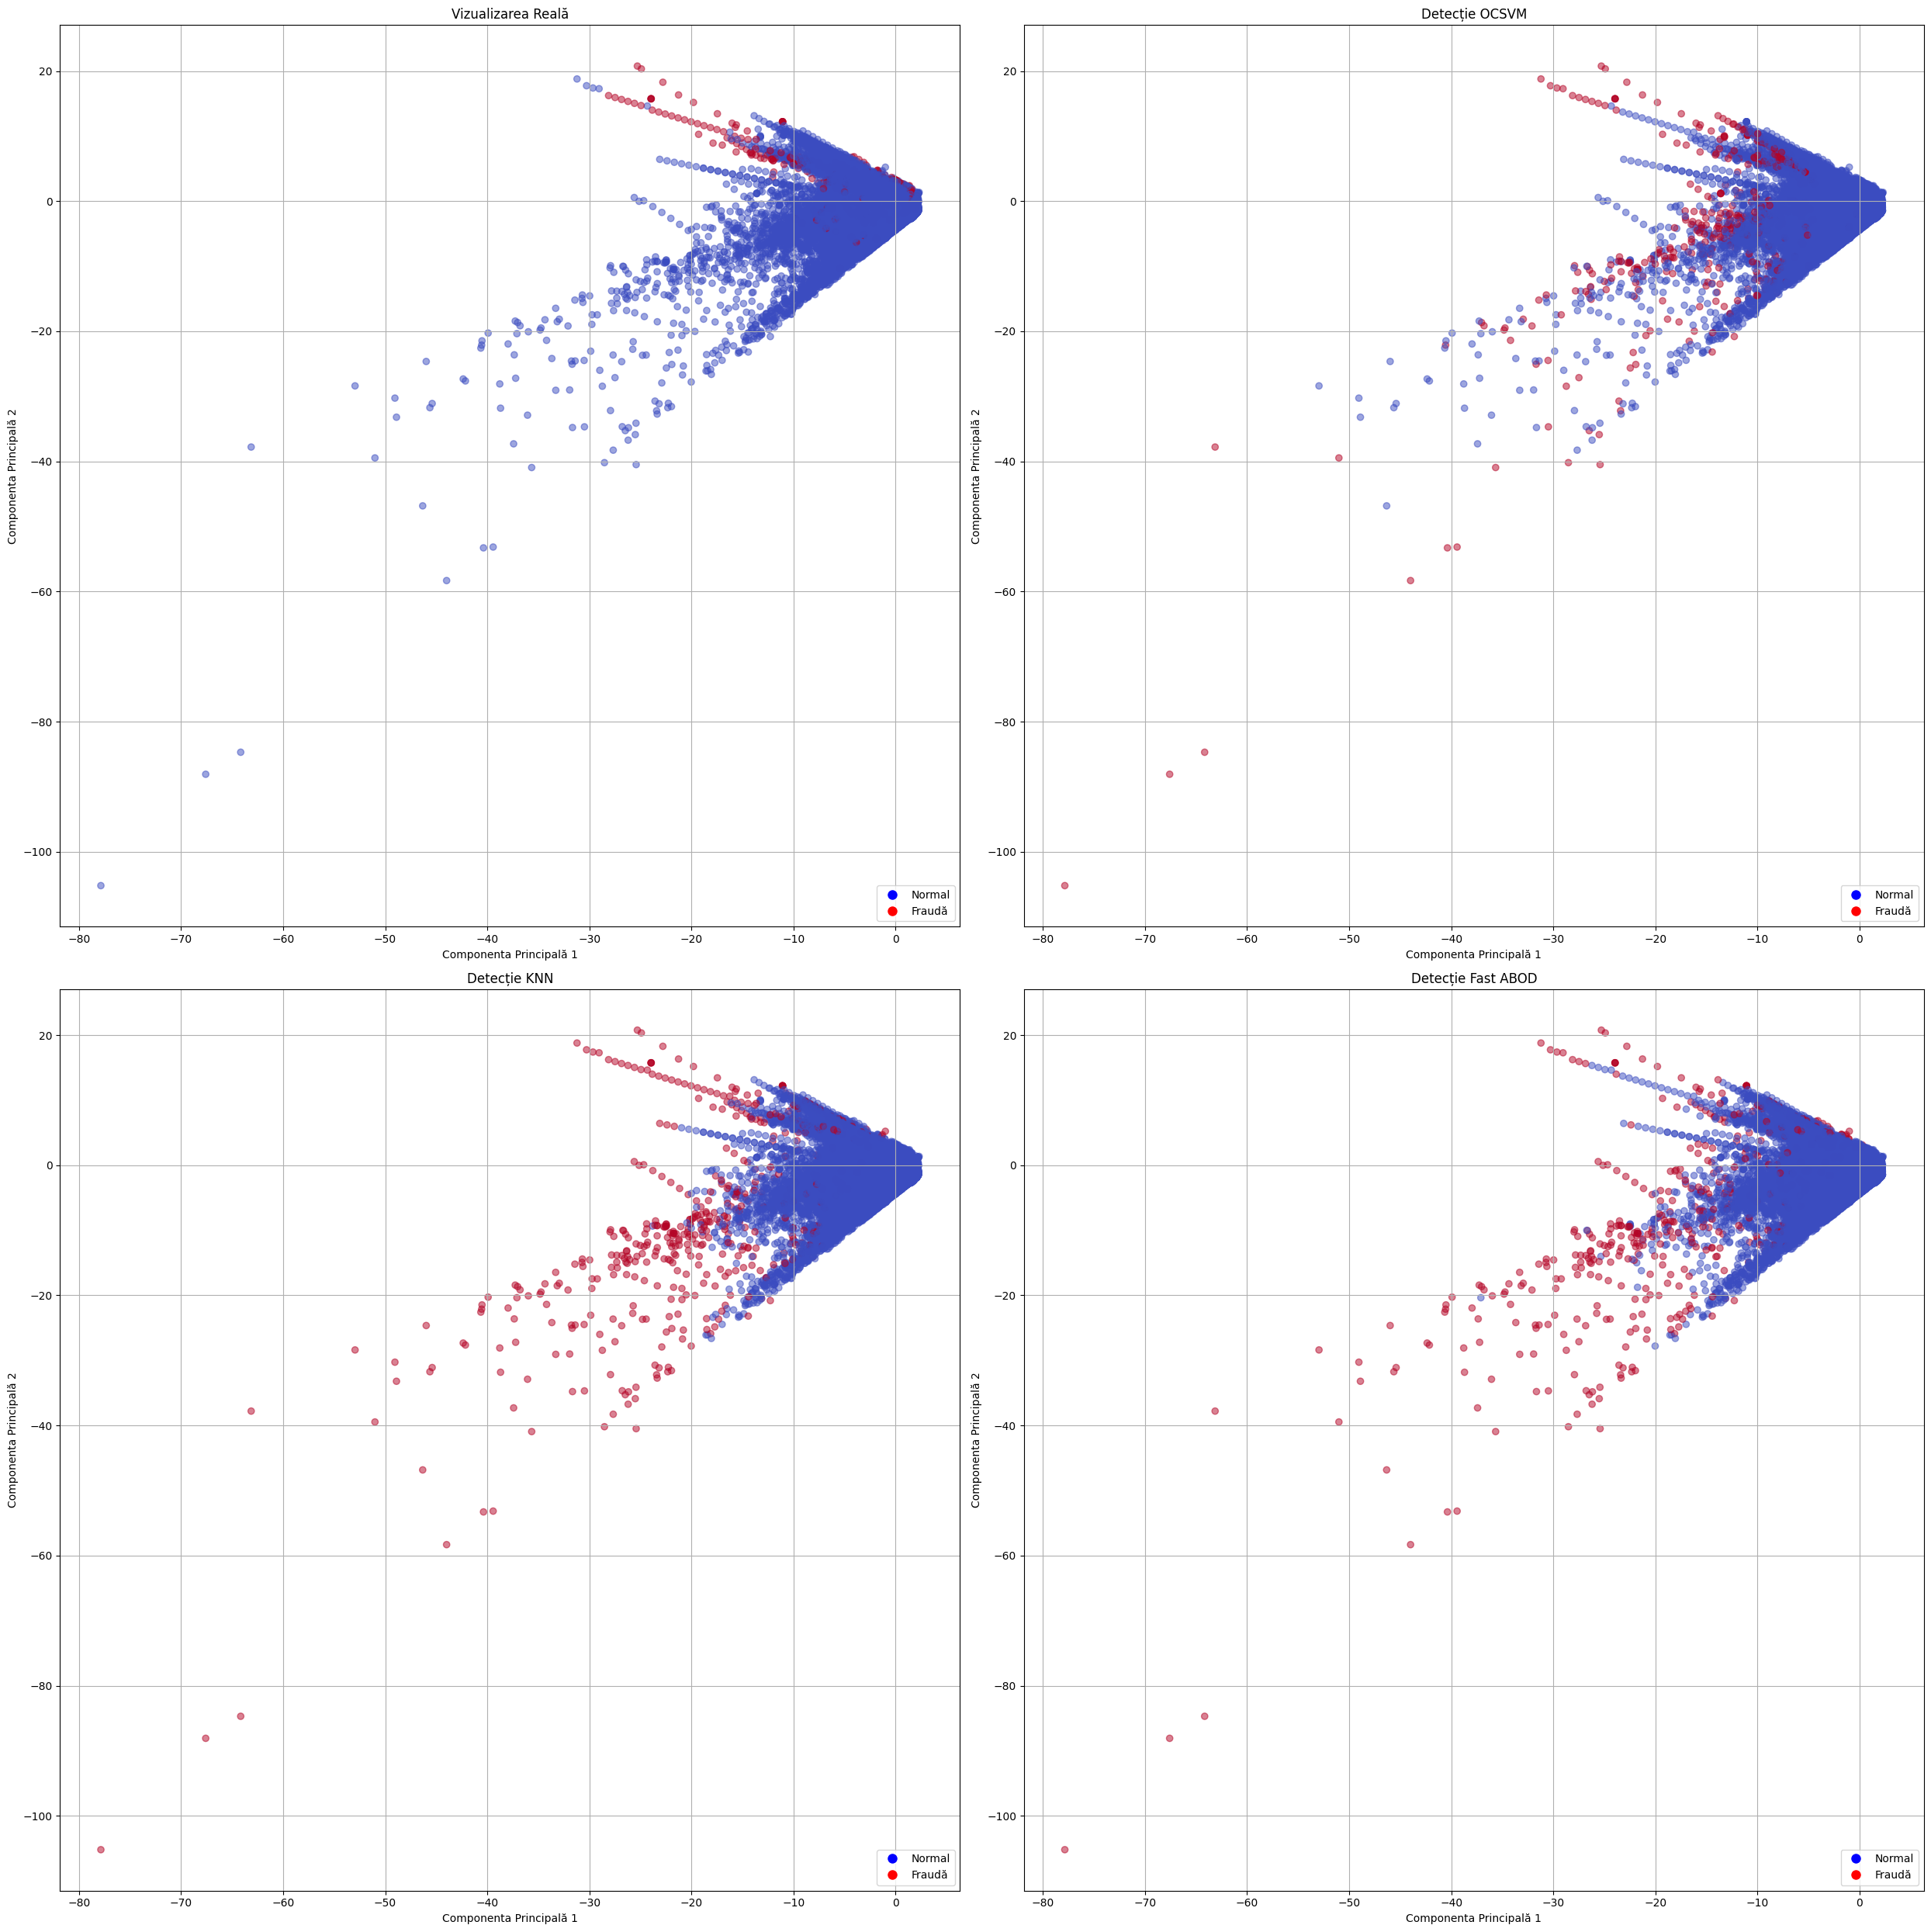

In [34]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# Reducem dimensiunile la 2 pentru vizualizare
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_clean)

# 1. Configurare grid (1 rând, 4 coloane)
fig, ax = plt.subplots(2, 2, figsize=(25, 25))

custom_legend = [
    Line2D([0], [0], marker='o', color='w', label='Normal',
           markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Fraudă',
           markerfacecolor='red', markersize=10)
]

# --- Graficul 1: REAL ---
s0 = ax[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Class'], cmap='coolwarm', alpha=0.5)
ax[0, 0].set_title('Vizualizarea Reală')
ax[0, 0].grid(True)
ax[0, 0].legend(handles = custom_legend, loc = 'lower right')
ax[0, 0].set_xlabel('Componenta Principală 1')
ax[0, 0].set_ylabel('Componenta Principală 2')

# --- Graficul 2: OCSVM ---
s1 = ax[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_ocsvm, cmap='coolwarm', alpha=0.5)
ax[0, 1].set_title('Detecție OCSVM')
ax[0, 1].grid(True) 
ax[0, 1].legend(handles = custom_legend, loc = 'lower right')
ax[0, 1].set_xlabel('Componenta Principală 1')
ax[0, 1].set_ylabel('Componenta Principală 2')

# --- Graficul 3: KNN ---
s2 = ax[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_knn, cmap='coolwarm', alpha=0.5)
ax[1, 0].set_title('Detecție KNN')
ax[1, 0].grid(True)
ax[1, 0].legend(handles = custom_legend, loc = 'lower right')
ax[1, 0].set_xlabel('Componenta Principală 1')
ax[1, 0].set_ylabel('Componenta Principală 2')

# --- Graficul 4: ABOD ---
s3 = ax[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_abod, cmap='coolwarm', alpha=0.5)
ax[1, 1].set_title('Detecție Fast ABOD')
ax[1, 1].grid(True)
ax[1, 1].legend(handles =custom_legend, loc = 'lower right')
ax[1, 1].set_xlabel('Componenta Principală 1')
ax[1, 1].set_ylabel('Componenta Principală 2')

plt.tight_layout()
plt.show()

Așa cum indică și **indicele Davies-Bouldin**, modelul **KNN** se apropie cel mai mult de situația reală, cu toate că nici acesta nu indică foarte bine tranzacțiile frauduloase. 

Un argument important pentru acest rezultat este că modelul **KNN** a fost antrenat pe toate datele, în timp ce **Fast ABOD** și **OCSVM** au fost antrenate pe eșantioane de $20.000$, respectiv de $50.000$ de date, datorită complexității ridicate a fiecărui algoritm, **Fast ABOD** fiind cel mai lent dintre cele 3 modele (deși a fost antrenat pe cel mai mic eșantion de date).

Cu toate acestea, performanțele lor sunt apropiate după ambii indici de performanță cu cea a modelului **KNN**. În plus, observăm că setul de date original este și un model dificil de antrenat inclusiv pentru modele de învățare nesupravegheată, deoarece tranzacțiile frauduloase sunt *amestecate* cu cele normale.

### **6. Bibliografie**
1. **Kriegel, H. P., Schubert, M., & Zimek, A. (2008).** *Angle-based outlier detection in high-dimensional data*. Proceedings of the 14th ACM SIGKDD international conference on Knowledge discovery and data mining. (Referința pentru algoritmul **ABOD**).
2. **Schölkopf, B., Platt, J. C., Shawe-Taylor, J., Smola, A. J., & Williamson, R. C. (2001).** *Estimating the Support of a High-Dimensional Distribution*. Neural Computation, 13(7), 1443-1471. (Referința teoretică pentru **OCSVM**).
3. **Manevitz, L. M., & Yousef, M. (2001).** *One-Class SVMs for Document Classification*. Journal of Machine Learning Research, 2, 139-154.
4. **Ramaswamy, S., Rastogi, R., & Shim, K. (2000).** *Efficient algorithms for mining outliers from large data sets*. ACM Sigmod Record, 29(2), 427-438. (Referința pentru detecția bazată pe **KNN**).
5. **Zhao, Y., Nasrullah, Z., & Li, Z. (2019).** *PyOD: A Python Toolbox for Scalable Outlier Detection*. Journal of Machine Learning Research, 20(96), 1-7. [Documentație Oficială PyOD](https://pyod.readthedocs.io/).
6. **Pedregosa, F., et al. (2011).** *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research. [Manual Scikit-learn](https://scikit-learn.org/).
7. **Davies, D. L., & Bouldin, D. W. (1979).** *A Cluster Separation Measure*. IEEE Transactions on Pattern Analysis and Machine Intelligence, (2), 224-227. (Fundamentul pentru **Davies-Bouldin Index**).
9. **Kaggle.** *Credit Card Fraud Detection Dataset*. [Referință Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). Colectat de Machine Learning Group (ULB).